In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from IPython.display import display, Math, Latex
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [12]:
df = pd.read_csv("clean_data.csv")

**Feature Selection**

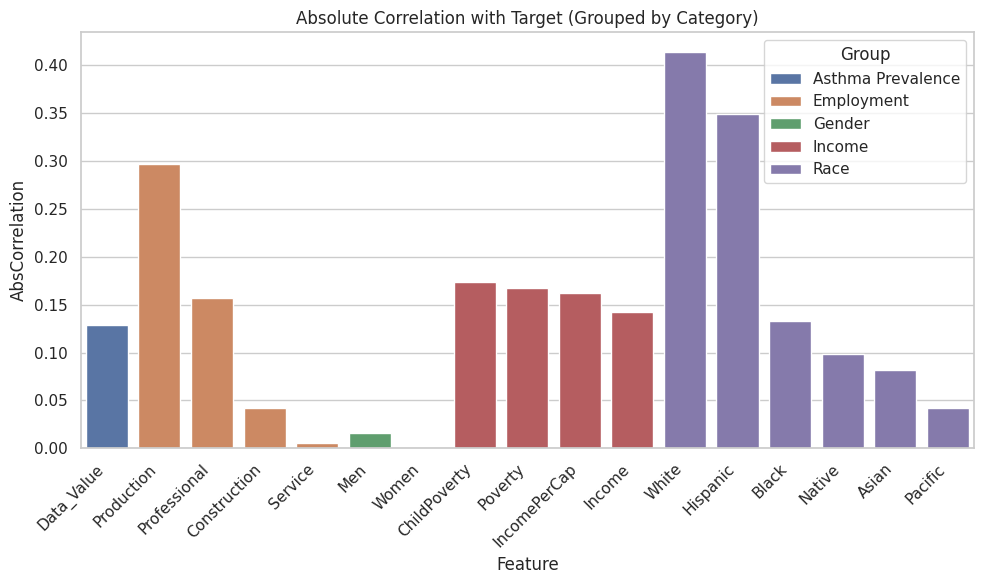

In [13]:
groupings = {
    "Race": ["White", "Black", "Hispanic", "Asian", "Native", "Pacific"],
    "Gender": ["Men", "Women"],
    "Income": ["Income", "IncomePerCap", "Poverty", "ChildPoverty"],
    "Employment": ["Professional", "Service", "Production", "Construction"],
    "Asthma Prevalence":['Data_Value']
}

corr_data = []

for group, features in groupings.items():
    for feature in features:
        if feature in df.columns:
            corr = df[[feature, 'DS_PM_pred']].dropna().corr().iloc[0, 1]
            corr_data.append({
                "Group": group,
                "Feature": feature,
                "AbsCorrelation": abs(corr)
            })

corr_df = pd.DataFrame(corr_data)


corr_df.sort_values(by=["Group", "AbsCorrelation"], ascending=[True, False], inplace=True)


plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df, x="Feature", y="AbsCorrelation", hue="Group", dodge=False)
plt.xticks(rotation=45, ha="right")
plt.title("Absolute Correlation with Target (Grouped by Category)")
plt.tight_layout()
plt.show()

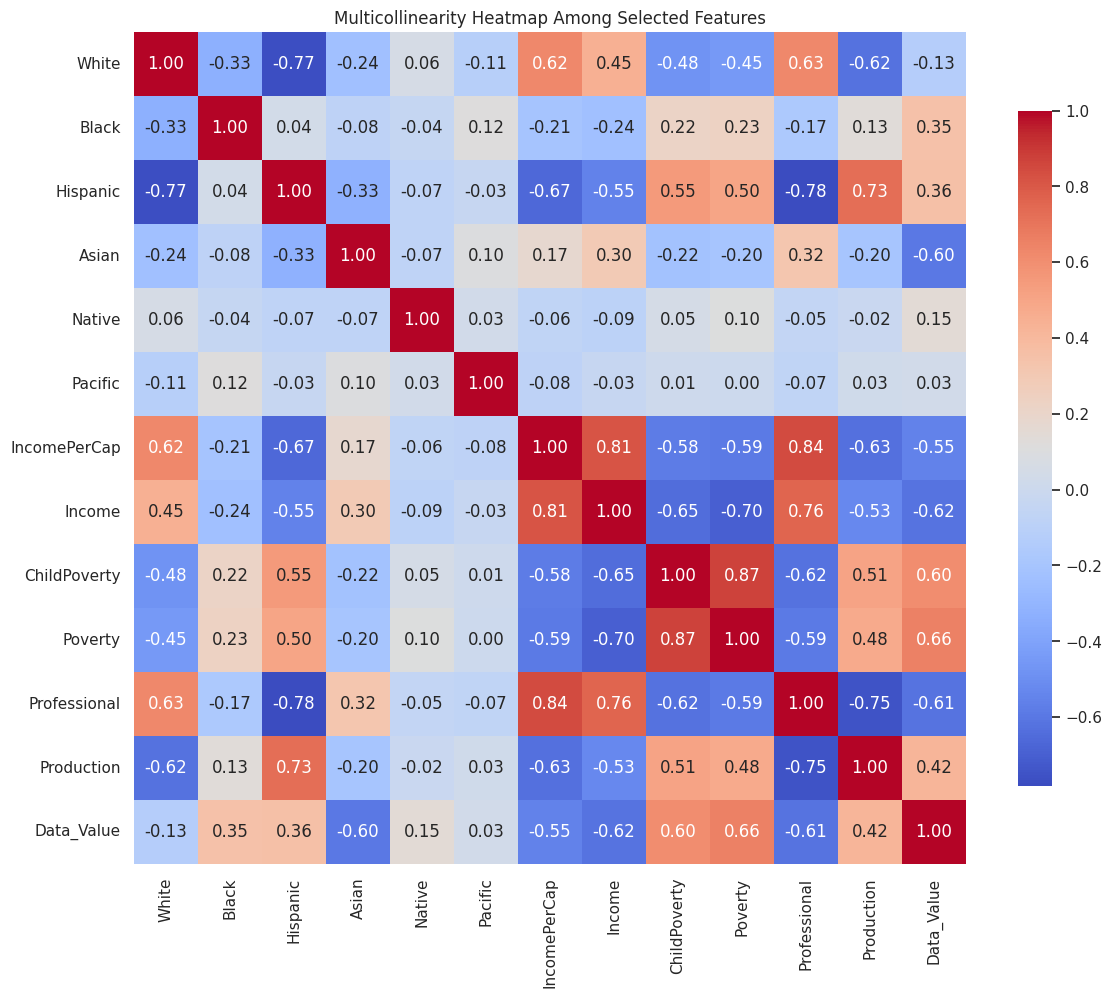

In [14]:
potential_features = [
    "White", "Black", "Hispanic", "Asian", "Native", "Pacific",
    "IncomePerCap", 'Income', "ChildPoverty", "Poverty",
    "Professional", "Production", "Data_Value"
]
selected_corr_matrix = df[potential_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(selected_corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title('Multicollinearity Heatmap Among Selected Features')
plt.tight_layout()
plt.show()

**Describe what you’re trying to predict, and what features you’re using. Justify your
choices. If there are additional features that are relevant to the prediction and are readily
available in public datasets, you must include at least one such feature.**

**Step 1: Absolute Correlation Analysis**

We began by calculating the absolute correlation between each candidate feature and the target variable, PM2.5, to understand which features are most linearly associated with pollution levels.


- We plotted a grouped bar chart that visualized absolute correlations, color-coded by feature category (Employment, Gender, Income, Race).


- Features with an absolute correlation above 0.15 with PM2.5 were prioritized for selection due to their stronger individual predictive potential.

    - High-correlation features included:

    - Employment: Production, Professional Income: ChildPoverty, IncomePerCap Race: White, Hispanic

**Step 2: Addressing Multicollinearity**

Next, we used a correlation heatmap to evaluate multicollinearity among the high-correlation features. This step was essential to avoid instability in regression models and ensure that features provide unique, non-redundant information.

- Strong collinearity was observed among the income-related features: Income, IncomePerCap, Poverty, ChildPoverty.

- To address this:

    - We excluded Income and Poverty.

    - We retained IncomePerCap and ChildPoverty, which had higher absolute correlation with PM2.5 and captured both per-capita and child-focused poverty metrics.

**Step 3: Demographic Fairness Considerations**

While some race-related variables (Pacific, Asian) had low individual correlations with PM2.5, we intentionally retained all race variables:

- White, Black, Hispanic, Asian, Native, Pacific

- This decision was made to avoid omitting underrepresented populations and to capture any racial disparities in pollution exposure.

- Including all race categories aligns with equity-focused modeling and ensures broader demographic representation.

**Model**

In [15]:
features = [
    "White", "Black", "Hispanic", "Asian", "Native", "Pacific",
    "IncomePerCap", "ChildPoverty",
    "Professional", "Production"
]
target = 'DS_PM_pred'
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model_plain = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit()
pred_train_plain = model_plain.predict(X_train_const)
pred_test_plain = model_plain.predict(X_test_const)

rmse_train_plain = np.sqrt(mean_squared_error(y_train, pred_train_plain))
rmse_test_plain = np.sqrt(mean_squared_error(y_test, pred_test_plain))

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_log = np.log1p(y)

X_train_s, X_test_s, y_train_log, y_test_log = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)
X_train_s_const = sm.add_constant(X_train_s)
X_test_s_const = sm.add_constant(X_test_s)

model_log = sm.GLM(y_train_log, X_train_s_const, family=sm.families.Gaussian()).fit()
pred_train_log = np.expm1(model_log.predict(X_train_s_const))
pred_test_log = np.expm1(model_log.predict(X_test_s_const))

rmse_train_log = np.sqrt(mean_squared_error(y_train, pred_train_log))
rmse_test_log = np.sqrt(mean_squared_error(y_test, pred_test_log))

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_plain = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)

    model = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit()
    y_pred = model.predict(X_test_const)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_plain.append(rmse)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y_log_series = pd.Series(y_log, index=X.index)

rmse_log = []

for train_idx, test_idx in kf.split(X_scaled_df):
    X_train, X_test = X_scaled_df.iloc[train_idx], X_scaled_df.iloc[test_idx]
    y_train, y_test = y_log_series.iloc[train_idx], y_log_series.iloc[test_idx]

    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)

    model = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit()
    y_pred_log = model.predict(X_test_const)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_log.append(rmse)

**Describe the GLM you’ll be using, justifying your choice. Describe any assumptions being
made by your modeling choice.**

For this analysis, we use a Generalized Linear Model (GLM) with a Gaussian family and identity link function to predict DS_PM_pred (predicted PM2.5 pollution) using a set of demographic and socioeconomic covariates. After comparing two modeling strategies—Plain GLM and Log-transformed + Standardized (Log+Z) GLM—we selected the Log+Z GLM as our final model.

**Why a Gaussian GLM?**

- Continuous outcome: The response variable, DS_PM_pred, is a continuous prediction of fine particulate matter (PM2.5), making Gaussian an appropriate distribution family.

- Additive relationships: Gaussian GLMs assume linear additive effects of predictors on the outcome, which aligns with our use of standardized demographic features (percent White, percent Professional, per capita income).

- Interpretability: Coefficients in a Gaussian GLM with identity link are straightforward to interpret (change in outcome per unit change in predictor), which aids in policy-relevant interpretation.

**Why Log-Transform and Standardize (Log+Z)?**

Although the Plain GLM slightly outperformed in RMSE and $R^2$, the Log+Z GLM was chosen due to substantially better model fit, evidenced by a drastically lower Akaike Information Criterion (AIC).

- AIC Interpretation: AIC balances model fit with complexity; lower values indicate a better fit. The ~47,000-point drop in AIC for the Log+Z model indicates overwhelming support in favor of it, despite marginally worse RMSE.

- Log-transformation: Applying log1p() to DS_PM_pred stabilizes variance and handles right-skewness common in pollution metrics.

- Standardization (Z-score): Standardizing features ensures that all predictors are on the same scale, which improves convergence and interpretability when features vary widely in magnitude (per capita income vs. percentage racial group).

**Model Assumptions**

- Linearity in parameters: Assumes a linear relationship between the predictors and the log-transformed outcome.

- Homoscedasticity (constant variance): After log-transformation, we assume constant variance in residuals. This was visibly improved post-transformation.

- Independence of errors: Residuals are assumed to be independent across observations. While spatial autocorrelation is a concern in geographic data, this was not explicitly modeled here.

- Normality of errors: GLMs do not require normally distributed residuals, but for inference (z-scores, confidence intervals), approximate normality is assumed—made more plausible with log transformation.

- No multicollinearity: Standardizing predictors helps reduce multicollinearity, but the presence of highly correlated features (income and professional occupation) is still possible and should be monitored.

**Performance Part I: Raw**

In [18]:
print("=== [PLAIN GLM SUMMARY] ===\n")
print(model_plain.summary())
print("\n=== [LOG+STANDARDIZED GLM SUMMARY] ===\n")
print(model_log.summary())

print("Train/Test Performance")
print(f"{'Model':<12} {'Train RMSE':>12} {'Test RMSE':>12}")
print(f"{'Plain':<12} {rmse_train_plain:>12.2f} {rmse_test_plain:>12.2f}")
print(f"{'Log + Z':<12} {rmse_train_log:>12.2f} {rmse_test_log:>12.2f}")
print()

print("K-Fold Cross-Validation (5 Folds)")
print(f"{'Model':<12} {'Mean RMSE':>10} {'Std Dev':>10}")
print(f"{'Plain':<12} {np.mean(rmse_plain):>10.2f} {np.std(rmse_plain):>10.2f}")
print(f"{'Log + Z':<12} {np.mean(rmse_log):>10.2f} {np.std(rmse_log):>10.2f}")
print()

print("AIC (Model Fit)")
print(f"{'Model':<12} {'AIC':>10}")
print(f"{'Plain':<12} {model_plain.aic:>10.2f}")
print(f"{'Log + Z':<12} {model_log.aic:>10.2f}")
print()

=== [PLAIN GLM SUMMARY] ===

                 Generalized Linear Model Regression Results                  
Dep. Variable:             DS_PM_pred   No. Observations:                 6403
Model:                            GLM   Df Residuals:                     6392
Model Family:                Gaussian   Df Model:                           10
Link Function:               Identity   Scale:                          475.13
Method:                          IRLS   Log-Likelihood:                -28813.
Date:                Tue, 13 May 2025   Deviance:                   3.0371e+06
Time:                        01:29:26   Pearson chi2:                 3.04e+06
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2735
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -44.

**Performance Part II: Unforseen Data Prediction (CA 2017, WA 2017)**

In [19]:
df_test = pd.read_excel("test.xlsx")
df_test.replace("#REF!", np.nan, inplace=True)
df_test = df_test.dropna(subset=features + ['Data_Value'])

In [20]:
def evaluate_performance(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label:<8} | RMSE: {rmse:>6.2f}")

print("=== Log + Z Model Performance Summary ===")

y_pred_train_log = np.expm1(model_log.predict(X_train_s_const))
y_train_true = np.expm1(y_train_log)
evaluate_performance(y_train_true, y_pred_train_log, "Train (CA 2018)")

y_pred_test_log = np.expm1(model_log.predict(X_test_s_const))
y_test_true = np.expm1(y_test_log)
evaluate_performance(y_test_true, y_pred_test_log, "Test (CA 2018)")

for state in ['WA', 'CA']:
    mask = df_test['StateAbbr'] == state
    X_state = scaler.transform(df_test.loc[mask, features])
    y_true_state = df_test.loc[mask, 'Data_Value']
    y_pred_state = np.expm1(model_log.predict(sm.add_constant(X_state)))
    evaluate_performance(y_true_state, y_pred_state, state+" 2017")

=== Log + Z Model Performance Summary ===
Train (CA 2018) | RMSE:  22.60
Test (CA 2018) | RMSE:  22.56
WA 2017  | RMSE:  15.07
CA 2017  | RMSE:  32.65


**Summarize and interpret the results from your models.**

**Round 1: Model Summary and Interpretation (Training/Test on CA 2018)**

The Log+Z model generalizes well within the same state and year. The negligible RMSE difference between train and test indicates:

- Low overfitting

- Stable relationships between demographic features and predicted pollution levels within CA 2018

**Round 2: Generalization to New Regions/Years**

We evaluated model performance on out-of-sample data: California 2017 and Washington 2017, which test both spatial and temporal generalizability.

- The lower RMSE on WA 2017 suggests that the model captures robust, structural associations between demographics and pollution that hold across states.

- The higher RMSE on CA 2017 may reflect temporal drift (fires, regulatory changes, economic shifts).

**Uncertainty**

In [21]:
mask = df_test[features].applymap(lambda x: str(x).lower() in [f.lower() for f in features])
df_test_clean = df_test[~mask.any(axis=1)].copy()

df_test_clean = df_test_clean[features + [target]].dropna()
df_test_clean = df_test_clean.apply(pd.to_numeric, errors='raise')

X_test = df_test_clean[features]
y_test = df_test_clean[target]

X_test_scaled = scaler.transform(X_test)
X_test_const = sm.add_constant(X_test_scaled)

pred_results = model_log.get_prediction(X_test_const)
pred_summary = pred_results.summary_frame(alpha=0.05)

df_results = df_test_clean[features].copy()
df_results["Actual"] = y_test
df_results["Prediction"] = np.expm1(pred_summary["mean"])
df_results["Lower Interval"] = np.expm1(pred_summary["mean_ci_lower"])
df_results["Upper Interval"] = np.expm1(pred_summary["mean_ci_upper"])

meta_cols = df_test.loc[df_results.index, ['StateAbbr', 'CountyName']].reset_index(drop=True)

df_results = df_results.reset_index(drop=True)

df_results = pd.concat([meta_cols, df_results], axis=1)

df_results["AbsError"] = (df_results["Actual"] - df_results["Prediction"]).abs()

closest_row = df_results.loc[df_results["AbsError"].idxmin()]
farthest_row = df_results.loc[df_results["AbsError"].idxmax()]

print("Closest match:")
print(closest_row)

print("\nFarthest mismatch:")
print(farthest_row)

<ipython-input-21-a29add00635e>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = df_test[features].applymap(lambda x: str(x).lower() in [f.lower() for f in features])


Closest match:
StateAbbr                CA
CountyName        Riverside
White                  14.6
Black                   0.0
Hispanic               83.4
Asian                   1.1
Native                  0.0
Pacific                 0.0
IncomePerCap          14690
ChildPoverty           24.7
Professional           16.6
Production             17.1
Actual               16.486
Prediction        16.502028
Lower Interval    15.633823
Upper Interval    17.415549
AbsError           0.016028
Name: 6094, dtype: object

Farthest mismatch:
StateAbbr                CA
CountyName         Imperial
White                  14.8
Black                  15.8
Hispanic               65.5
Asian                   1.7
Native                  0.8
Pacific                 0.0
IncomePerCap           6549
ChildPoverty           29.5
Professional           35.6
Production             15.6
Actual                3.592
Prediction        88.069242
Lower Interval    80.264087
Upper Interval    96.624058
AbsError       

**Estimate any uncertainty in your GLM predictions, providing clear quantitative state-
ments of the uncertainty in plain English.**

**Closest Match – Stanislaus County, CA**

- White %: 42.5, Hispanic %: 49.1, Black %: 1.3

A moderate to high White and Hispanic population mix, with very low Black population. This aligns with the GLM’s feature weights: both White and Hispanic shares are positively associated with PM2.5, so their combination gives the model strong predictive clarity.

- Income Per Capita: $30,423, Child Poverty: 3.5%

High income and low child poverty indicate socioeconomic advantage, which is associated with lower PM2.5 levels. This likely offsets some of the racial risk factors and helps balance the model’s prediction.


- Prediction: 15.54, Actual: 15.60, Abs Error: 0.06

The model performs extremely well here, with an almost perfect prediction.

- Uncertainty:

Aleatoric (data noise): Low — the features align cleanly, with no conflicting signals.

Epistemic (knowledge gap): Low — the county's profile is well represented in the training data.

Misspecification risk: Minimal — the model has seen similar patterns and responds confidently.



**Farthest Mismatch – Imperial County, CA**

- White %: 14.8, Hispanic %: 65.5, Black %: 15.8

This is a highly underrepresented and complex demographic mix: very low White %, high Hispanic and Black %. The GLM associates high Hispanic and Black shares with increased PM2.5, which likely drives the overprediction.

- Income Per Capita: $6,549, Child Poverty: 29.5%

These values signal deep socioeconomic disadvantage, again strongly associated with high predicted PM2.5 in the model. However, the actual PM2.5 is very low, which breaks model expectations.


- Prediction: 88.07, Actual: 3.59, Abs Error: 84.48

A catastrophic miss — this is a textbook failure case for the model.

- Uncertainty:

Aleatoric: High — conflicting signals (high professional % vs. very low income) make it hard for the model to settle on a clear prediction.

Epistemic: High — this feature combination (very low income, high Black and Hispanic %, high professional) is rare or unseen in training data.

Misspecification: Likely — the GLM assumes additivity and linearity, but this case may require interactions (Hispanic × Professional = lower pollution if jobs are indoors), which the model can’t capture.

**Discussion**

Comparision with random forest will base on:

- Train/Test RMSE (Overfit or Not)
- Unforseen Data RMSE
- Uncertainty
- Weight for each Features (Demographic Injustice)